# Particle tracking — passive tagging of production channels

PriNCe's **tracking species** feature adds passive duplicate species to the state vector that record the production a real daughter receives from a chosen parent set / process class. The duplicate gets its own state-vector slot under a synthetic PDG ID, evolves under the same single-particle dynamics as its real counterpart, but its decay/interaction products do **not** feed back into the network — so the real-species flux is left bit-identical to a baseline (no-tracking) run.

Three demos in this notebook, each adapted from the design's motivating cases (`wiki/methods/tracking-species-design.md`):

1. **ν̄_e from neutron decay.** Explicit-decay mode (`config.enable_explicit_decay=True`) keeps the neutron in the state vector; the tracked ν̄_e records the β-decay daughters. With a He-4 source the only ν̄_e source is n-β-decay, so tracked-ν̄_e matches real ν̄_e at the dominant bins (validation of the Λ_off accumulator path).

2. **Neutron from p → n charge exchange.** Same explicit-decay setup. Real-n picks up flux from both photo-disintegration of He-4 (direct (He-4, n) channel) AND photo-hadronic conversion of free protons. The tracked-n with `parent_pdgs=[2212]` isolates just the proton-CX route, so tracked-n ≤ real-n with strict inequality wherever (He-4, n) dominates.

3. **Photon-energy regime partition for protons from He-4.** Default chain-reducer mode. Three tracked-p species partition the lab-frame photon-energy axis into disjoint buckets (low / mid / high). Their sum reproduces a fourth tracker with no `e_gamma_range` window to machine precision — a sum-rule that follows from the mask being a linear filter on the photon-energy axis. Useful when one wants to attribute a real-species' flux to a specific portion of the target photon field (e.g. CMB vs CIB).

Setup mirrors `Direct_vs_explicit_decay.ipynb`: `max_mass=4`, He-4 Auger-fit source, propagation z=1→0 on the scipy backend, `dz=1e-3` (1000 ETD2 steps).

In [1]:
# Point PriNCe at the FLUKA-derived photo-nuclear database (v3 prod).
# Override fluka_db_path / fluka_db_fname for a different machine.
import prince_cr.config
prince_cr.config.fluka_db_path = '/Users/anatoli/devel_mac/UH-UHECR-Fluka-Prince/runs/2026-05-06_pfu-v3-prod/outputs'
prince_cr.config.fluka_db_fname = 'prince_db_v3-sparse.h5'

CUPY not found for GPU support. Degrading to MKL.
MKL runtime not found. Degrading to scipy.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from prince_cr import core, photonfields, cross_sections
from prince_cr.cr_sources import AugerFitSource
from prince_cr.solvers import UHECRPropagationSolverETD2

In [3]:
# Standard PriNCe physics knobs.
prince_cr.config.x_cut = 1e-4
prince_cr.config.x_cut_proton = 1e-2
prince_cr.config.tau_dec_threshold = np.inf

In [4]:
pf = photonfields.CombinedPhotonField(
    [photonfields.CMBPhotonSpectrum, photonfields.CIBGilmore2D]
)

In [5]:
def make_run(*, enable_explicit_decay, tracked_species=None, max_mass=4):
    """Build a fresh PriNCeRun with optional tracking specs.

    ``tracked_species`` is the list of kwargs dicts passed through to
    ``SpeciesManager.add_tracking_species`` after the species manager
    is built but before interaction rates are sized. Each call builds
    a fresh cross-section instance because the chain-reducer gate is
    consumed once per FlukaPhotoNuclear, and `emit_tracking_channels`
    mutates the channel dicts in place.
    """
    saved = getattr(prince_cr.config, 'enable_explicit_decay', False)
    prince_cr.config.enable_explicit_decay = enable_explicit_decay
    try:
        cs = cross_sections.FlukaPhotoNuclear(max_mass=max_mass)
        return core.PriNCeRun(
            max_mass=max_mass, photon_field=pf, cross_sections=cs,
            tracked_species=tracked_species or [],
        )
    finally:
        prince_cr.config.enable_explicit_decay = saved


def make_solver(prince_run, *, enable_decay, source_params):
    prince_run.backend.linear_algebra_backend = 'scipy'
    s = UHECRPropagationSolverETD2(
        initial_z=1.0,
        final_z=0.0,
        prince_run=prince_run,
        enable_pairprod_losses=True,
        enable_adiabatic_losses=True,
        enable_injection_jacobian=True,
        enable_partial_diff_jacobian=True,
        enable_decay=enable_decay,
    )
    s.add_source_class(AugerFitSource(prince_run, norm=1e-50, params=source_params))
    return s


def get_spectrum(state, spec_man, key):
    """Pull a species' state slice; key can be a PDG int or sname str."""
    if isinstance(key, str):
        s = spec_man.sname2sref.get(key)
    else:
        s = spec_man.pdgid2sref.get(key)
    return None if s is None else state[s.lidx():s.uidx()]


def masked(y, mask):
    out = np.full_like(y, np.nan, dtype=float)
    out[mask] = y[mask]
    return out


# Shared He-4 Auger-fit source spec — used as injection in every demo.
AUGER_HE4 = {1000020040: (0.96, 10**9.68, 50.0)}

## Demo 1 — ν̄_e from neutron decay

Explicit-decay mode (`config.enable_explicit_decay=True`) keeps free neutron in the state vector. The Λ operator carries the β-decay distribution into ν̄_e (PDG = −12) via `_ensure_Lambda_split`'s off-diagonal block.

We register **one tracked ν̄_e** with `parent_pdgs=[2112]` (neutron) and `process_class='decay'`. Since the only ν̄_e production route in this max_mass=4 setup IS neutron β-decay, tracked ν̄_e should exactly equal real ν̄_e at the dominant bins. Below the rounding floor (~1 % of peak) the two oscillate against each other — ETD2 propagates tracked and real rows through different sparse-matrix layouts and FP cancellations in the decay tail diverge at the noise level.

In [6]:
tracking_nu = [
    dict(parent_pdgs=[2112], daughter_pdg=-12,
         process_class='decay', alias='nuebar_from_n'),
]
%time prince_run_nu = make_run(enable_explicit_decay=True, tracked_species=tracking_nu)

PriNCeRun::__init__(): initialising Energy grid
PhotoNuclearInteractionRate::_init_coupling_mat(): Initiating coupling matrix in (CSR) format
CPU times: user 557 ms, sys: 77.8 ms, total: 635 ms
Wall time: 667 ms


In [7]:
solver_nu = make_solver(prince_run_nu, enable_decay=True, source_params=AUGER_HE4)
%time solver_nu.solve(dz=1e-3, verbose=False, progressbar=True)

100%|██████████| 1000/1000 [00:00<00:00, 1870.58it/s]

CPU times: user 530 ms, sys: 31.5 ms, total: 562 ms
Wall time: 566 ms


bins above   0.5 × peak ( 17 bins):  max |trk - real| / |real| = 2.56e-04
bins above   0.1 × peak ( 26 bins):  max |trk - real| / |real| = 2.88e-03
bins above  0.01 × peak ( 28 bins):  max |trk - real| / |real| = 2.41e-02


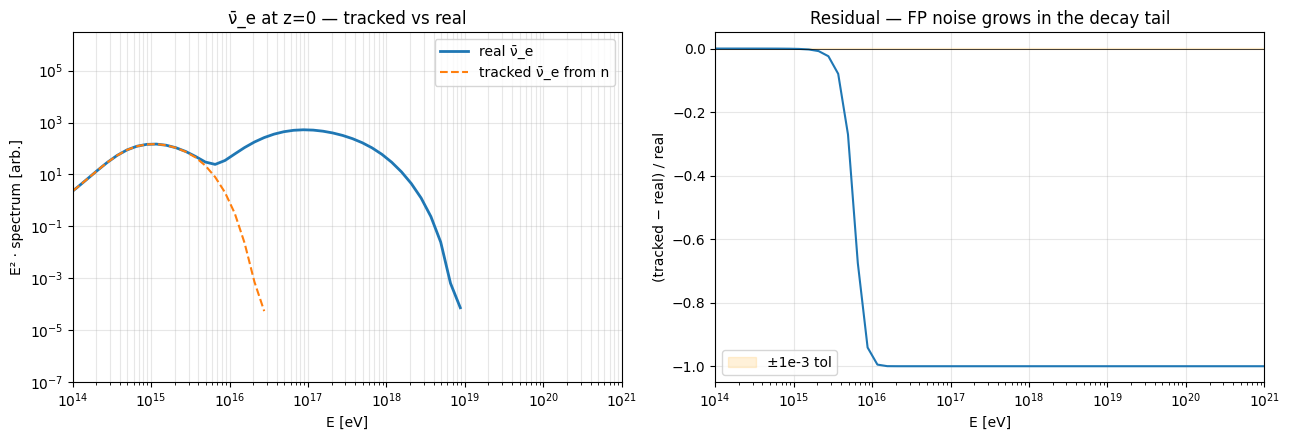

In [19]:
e_grid_GeV = prince_run_nu.cr_grid.grid
e_eV = e_grid_GeV * 1e9
e2 = e_eV**2

real_nu = get_spectrum(solver_nu.state, solver_nu.spec_man, -12)
trk_nu = get_spectrum(solver_nu.state, solver_nu.spec_man, 'nuebar_from_n')

peak = np.max(np.abs(real_nu))
for frac in (0.5, 0.1, 0.01):
    sig = np.abs(real_nu) > frac * peak
    if sig.any():
        rd = np.max(np.abs(trk_nu[sig] - real_nu[sig]) / np.abs(real_nu[sig]))
        print(f'bins above {frac:>5g} × peak ({sig.sum():>3d} bins):  '
              f'max |trk - real| / |real| = {rd:.2e}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.loglog(e_eV, masked(e2 * real_nu, real_nu > 0),
           label='real ν̄_e', lw=2)
ax1.loglog(e_eV, masked(e2 * trk_nu, trk_nu > 0), '--',
           label='tracked ν̄_e from n')
ax1.set_xlabel('E [eV]')
ax1.set_ylabel('E² · spectrum [arb.]')
ax1.set_title('ν̄_e at z=0 — tracked vs real')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3, which='both')
ax1.set_ylim(1e-7)
ax1.set_xlim(1e14,1e21)

nz = (np.abs(real_nu) > 0) & (np.abs(trk_nu) > 0)
resid = np.full_like(real_nu, np.nan, dtype=float)
resid[nz] = (trk_nu[nz] - real_nu[nz]) / real_nu[nz]
ax2.semilogx(e_eV, resid)
ax2.axhline(0, color='k', lw=0.5)
ax2.axhspan(-1e-3, 1e-3, alpha=0.15, color='orange', label='±1e-3 tol')
ax2.set_xlabel('E [eV]')
ax2.set_ylabel('(tracked − real) / real')
ax2.set_title('Residual — FP noise grows in the decay tail')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_xlim(1e14,1e21)
fig.tight_layout()
plt.show()

## Demo 2 — Neutrons from p → n charge exchange

Same explicit-decay setup. The state vector carries free n (PDG 2112). Real n receives flux from (a) direct photo-disintegration channels of He-4, e.g. (He-4 → ³He + n), and (b) photo-hadronic conversion of free protons via the (p, n) channel. The chain reducer is bypassed in explicit-decay mode so both contributions reach n directly through M_off.

Register a tracked n with `parent_pdgs=[2212]` and `process_class='photo-nuclear'`: only the proton → n route enters the tracker. We expect tracked-n ≤ real-n at every bin, with strict inequality wherever (He-4, n) is the dominant contribution.

Note: in default chain-reducer mode the neutron decays out of the state vector (`tau_dec_threshold=np.inf` folds its branching into ν̄_e + p), so neutron tracking is only meaningful with `enable_explicit_decay=True`.

In [9]:
tracking_n = [
    dict(parent_pdgs=[2212], daughter_pdg=2112,
         process_class='photo-nuclear', alias='n_from_p'),
]
%time prince_run_n = make_run(enable_explicit_decay=True, tracked_species=tracking_n)

PriNCeRun::__init__(): initialising Energy grid
PhotoNuclearInteractionRate::_init_coupling_mat(): Initiating coupling matrix in (CSR) format
CPU times: user 509 ms, sys: 52.4 ms, total: 562 ms
Wall time: 562 ms


In [10]:
solver_n = make_solver(prince_run_n, enable_decay=True, source_params=AUGER_HE4)
%time solver_n.solve(dz=1e-3, verbose=False, progressbar=True)

100%|██████████| 1000/1000 [00:00<00:00, 1861.88it/s]

CPU times: user 531 ms, sys: 9.21 ms, total: 540 ms
Wall time: 543 ms


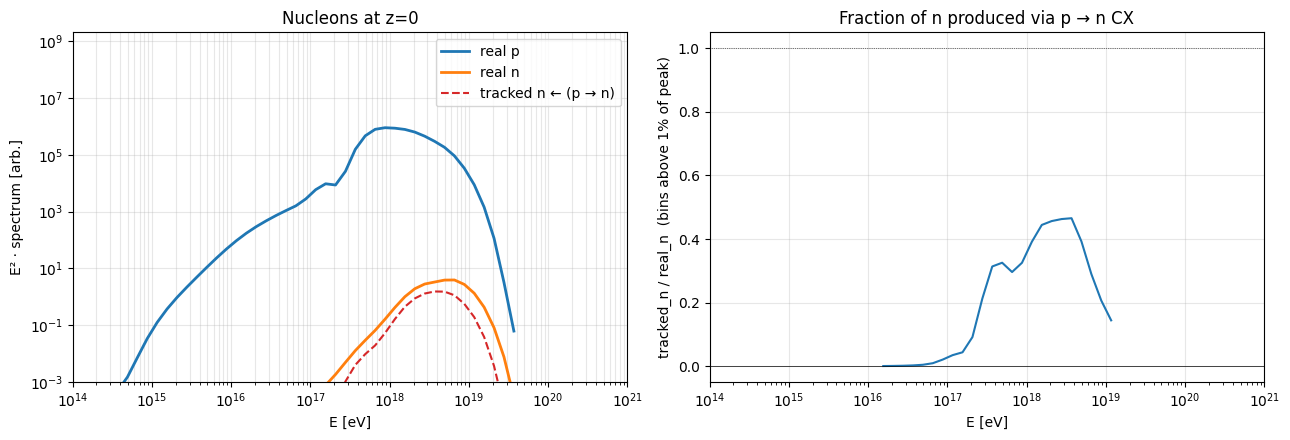

over bins where real_n >= 1% of peak (24 bins):
  min tracked/real = 0.001
  max tracked/real = 0.465  (≤ 1 ⇒ passive-observer bound holds)
  integrated ratio = 0.374  (fraction of n flux explained by p → n CX in this band)


In [23]:
real_n = get_spectrum(solver_n.state, solver_n.spec_man, 2112)
trk_n = get_spectrum(solver_n.state, solver_n.spec_man, 'n_from_p')
real_p = get_spectrum(solver_n.state, solver_n.spec_man, 2212)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.loglog(e_eV, masked(e2 * real_p, real_p > 0), label='real p', lw=2, color='C0')
ax.loglog(e_eV, masked(e2 * real_n, real_n > 0), label='real n', lw=2, color='C1')
ax.loglog(e_eV, masked(e2 * trk_n, trk_n > 0), '--',
          label='tracked n ← (p → n)', color='C3')
ax.set_xlabel('E [eV]')
ax.set_ylabel('E² · spectrum [arb.]')
ax.set_title('Nucleons at z=0')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which='both')
ax.set_xlim(1e14,1e21)
ax.set_ylim(1e-3)

ax = axes[1]
# Restrict the fraction plot to bins where the real-n flux is well above
# the FP rounding floor (>= 1% of its peak). Below that the tracked /
# real signs flip and the ratio overshoots 1 from FP cancellation noise
# in either accumulator — not a physical violation of the passive-
# observer bound.
peak_n = np.max(np.abs(real_n))
sig = real_n > 1e-2 * peak_n
frac = np.full_like(real_n, np.nan, dtype=float)
frac[sig] = trk_n[sig] / real_n[sig]
ax.semilogx(e_eV, frac)
ax.axhline(0, color='k', lw=0.5)
ax.axhline(1, color='k', lw=0.5, ls=':')
ax.set_xlabel('E [eV]')
ax.set_ylabel('tracked_n / real_n  (bins above 1% of peak)')
ax.set_title('Fraction of n produced via p → n CX')
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)
ax.set_xlim(1e14,1e21)
fig.tight_layout()
plt.show()

if sig.any():
    print(f'over bins where real_n >= 1% of peak ({sig.sum()} bins):')
    print(f'  min tracked/real = {np.min(frac[sig]):.3f}')
    print(f'  max tracked/real = {np.max(frac[sig]):.3f}  (≤ 1 ⇒ passive-observer bound holds)')
    integrated_ratio = np.sum(trk_n[sig]) / np.sum(real_n[sig])
    print(f'  integrated ratio = {integrated_ratio:.3f}  '
          f'(fraction of n flux explained by p → n CX in this band)')

## Demo 3 — Photon-energy regime partition

Default chain-reducer mode (proton is stable and survives reduction). Register **three tracked-p species** that partition the lab-frame photon-energy axis (`ph_grid.grid`, in GeV) into disjoint buckets, plus a fourth unrestricted tracker that records the union. The implementation applies a static mask on the photon-energy axis at kernel-build time — masked bins drop out of the (mo, tracked_pdg) tile but the (mo, real_da) tile is unaffected.

Bucket boundaries are chosen on physical landmarks of the target field: the CMB blackbody (peak ~6e-13 GeV ≈ 0.6 meV at z=0), the transition to the CIB (~1e-10 GeV ≈ 0.1 eV), and the CIB itself. They form three disjoint windows covering `[0, ∞)`:

| bucket | lower [GeV] | upper [GeV] | physical role |
|---|---|---|---|
| `lo` | 0       | 1e-11 | CMB blackbody (peak ≈ 6e-13 GeV) |
| `mid` | 1e-11   | 1e-9  | CMB tail / CIB transition |
| `hi` | 1e-9    | ∞      | CIB |

Sum-rule expectation: the three partitioned trackers add to the unrestricted tracker to machine precision (the masks tile the photon axis exactly, the convolution is linear in the kernel). This is the load-bearing invariant for the `e_gamma_range` feature.

In [12]:
PHOTON_BUCKETS = [
    ('lo',  (0.0,    1e-11)),
    ('mid', (1e-11,  1e-9)),
    ('hi',  (1e-9,   np.inf)),
]

tracked_specs = [
    # Unrestricted tracker — sum-rule reference.
    dict(parent_pdgs=[1000020040], daughter_pdg=2212,
         process_class='photo-nuclear', alias='p_from_He4_all'),
]
for label, (lo, hi) in PHOTON_BUCKETS:
    tracked_specs.append(dict(
        parent_pdgs=[1000020040], daughter_pdg=2212,
        process_class='photo-nuclear', e_gamma_range=(lo, hi),
        alias=f'p_from_He4_{label}',
    ))

%time prince_run_part = make_run(enable_explicit_decay=False, tracked_species=tracked_specs)

PriNCeRun::__init__(): initialising Energy grid
PhotoNuclearInteractionRate::_init_coupling_mat(): Initiating coupling matrix in (CSR) format
CPU times: user 341 ms, sys: 27.4 ms, total: 368 ms
Wall time: 372 ms


In [13]:
solver_part = make_solver(prince_run_part, enable_decay=False, source_params=AUGER_HE4)
%time solver_part.solve(dz=1e-3, verbose=False, progressbar=True)

100%|██████████| 1000/1000 [00:00<00:00, 3398.48it/s]

CPU times: user 289 ms, sys: 7.33 ms, total: 296 ms
Wall time: 296 ms


partition sum vs unrestricted:
  max |sum - all|         = 2.050e-39
  max |sum - all| / max|all| = 7.613e-09


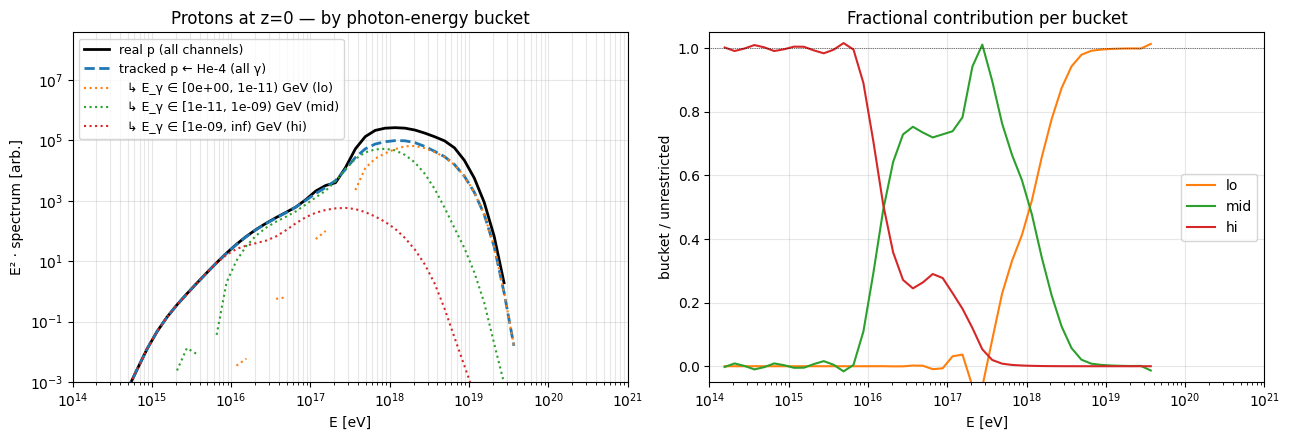

In [24]:
trk_all = get_spectrum(solver_part.state, solver_part.spec_man, 'p_from_He4_all')
trk_parts = {
    label: get_spectrum(solver_part.state, solver_part.spec_man, f'p_from_He4_{label}')
    for label, _ in PHOTON_BUCKETS
}
real_p = get_spectrum(solver_part.state, solver_part.spec_man, 2212)
partsum = sum(trk_parts.values())

max_abs = np.max(np.abs(trk_all))
max_diff = np.max(np.abs(partsum - trk_all))
print(f'partition sum vs unrestricted:')
print(f'  max |sum - all|         = {max_diff:.3e}')
print(f'  max |sum - all| / max|all| = {max_diff / max_abs:.3e}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.loglog(e_eV, masked(e2 * real_p, real_p > 0),
          label='real p (all channels)', color='k', lw=2)
ax.loglog(e_eV, masked(e2 * trk_all, trk_all > 0), '--',
          label='tracked p ← He-4 (all γ)', color='C0', lw=2)
colors = ['C1', 'C2', 'C3']
for (label, (lo, hi)), c in zip(PHOTON_BUCKETS, colors):
    y = trk_parts[label]
    legend = f'  ↳ E_γ ∈ [{lo:.0e}, {hi:.0e}) GeV ({label})'
    ax.loglog(e_eV, masked(e2 * y, y > 0), ls=':', color=c, label=legend)
ax.set_xlabel('E [eV]')
ax.set_ylabel('E² · spectrum [arb.]')
ax.set_title('Protons at z=0 — by photon-energy bucket')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')
ax.set_xlim(1e14,1e21)
ax.set_ylim(1e-3)

ax = axes[1]
nz = trk_all > 0
for (label, _), c in zip(PHOTON_BUCKETS, colors):
    frac = np.full_like(trk_all, np.nan, dtype=float)
    frac[nz] = trk_parts[label][nz] / trk_all[nz]
    ax.semilogx(e_eV, frac, color=c, label=label)
ax.axhline(1, color='k', lw=0.5, ls=':')
ax.set_xlabel('E [eV]')
ax.set_ylabel('bucket / unrestricted')
ax.set_title('Fractional contribution per bucket')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(1e14,1e21)
fig.tight_layout()
plt.show()

## What to look for

- **Demo 1 (ν̄_e from n):** the residual panel should hug zero across the high-flux band. Below ~1 % of peak the curve oscillates as ETD2 propagates tracked / real rows against different sparse layouts — that's FP noise, not physics.

- **Demo 2 (n from p):** `tracked_n / real_n` is the *fraction of free neutrons produced via charge-exchange of free protons*. The remainder is the direct (He-4, n) photo-disintegration channel. Energies where the He-4 photo-disintegration is on resonance show low fractions; energies where photons-on-protons dominates push the fraction toward 1.

- **Demo 3 (photon partition):** the printed `max|sum - all| / max|all|` should be at machine-precision (≲ 1e-10) — the sum-rule is exact algebraically and limited only by FP round-off in the SpMV accumulation. The bottom-right panel shows which photon regime (CMB low / mid / CIB hi) produces which CR-energy band's protons, illustrating the GZK-like map between photon and CR energies.

**Implementation cross-references:**
- Design: `wiki/methods/tracking-species-design.md`
- Tests: `tests/test_tracking_species.py`
- Source hooks: `prince_cr/{data,interaction_rates,cross_sections/base,solvers/propagation}.py`, `core.py`'s `tracked_species=[...]` kwarg.

**Known v1 limitations** (full list in the design page's `Status` block):
- `process_class` is honoured loosely — no per-emission `came_via_decay` flag.
- Tracked species don't get a photo-nuclear loss diagonal (synthetic PDGs fail `is_nucleus`, so the kernel skips them as mothers). Neutrino tracking is unaffected; neutron tracking inherits its β-decay Λ_diag but not photo-disintegration absorption.
- `e_gamma_range` applies on the **lab-frame** photon grid (PriNCe's `ph_grid.grid`, in GeV) — not on the rest-frame y variable. Use this to partition by photon source (CMB / CIB / EBL band); rest-frame regime splits (GDR / QD / π) would need an adapter.